In [586]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [587]:
df = pd.read_csv(r"C:\Coding\AIML\ML Projects\House-Price-Prediction\Dataset\train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


# EDA

In [588]:
print(df.shape)
df.columns

(1460, 81)


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [589]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [590]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [591]:
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [592]:
df.select_dtypes(include=['object']).columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [593]:
print(len(df.select_dtypes(include=['object']).columns))
print(len(df.select_dtypes(exclude=['object']).columns))

43
38


In [594]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [595]:
df.isnull().sum()[df.isnull().sum()>0].sort_values(ascending=False)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

<Axes: xlabel='SalePrice'>

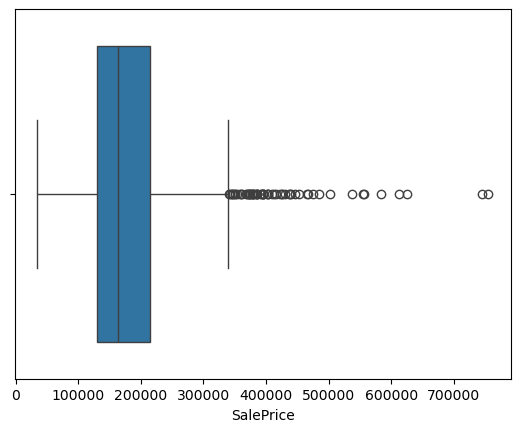

In [640]:
sns.boxplot(data=df,x='SalePrice')

<Axes: xlabel='SalePrice', ylabel='Count'>

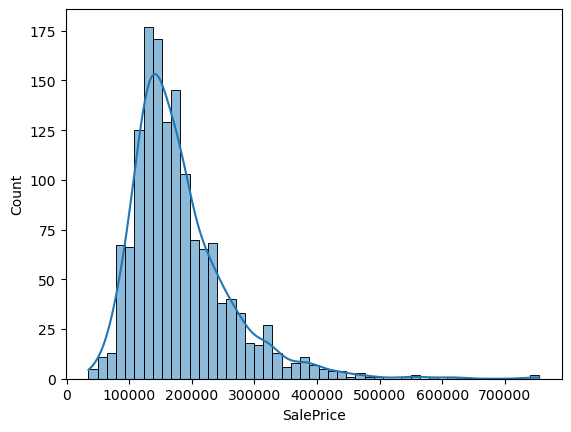

In [643]:
sns.histplot(data=df,x='SalePrice',kde=True)

**Right Skewed Distribution**

# Train Test split and handling missing values

In [596]:
X=df.drop('SalePrice',axis=1)
y = df['SalePrice']

In [597]:
print(X.shape)
y.shape

(1460, 80)


(1460,)

In [598]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [599]:
X_train.isnull().sum()[X_train.isnull().sum() > 0].sort_values(ascending=False)

PoolQC          1162
MiscFeature     1122
Alley           1094
Fence            935
MasVnrType       683
FireplaceQu      547
LotFrontage      217
GarageType        64
GarageYrBlt       64
GarageFinish      64
GarageQual        64
GarageCond        64
BsmtCond          28
BsmtFinType1      28
BsmtExposure      28
BsmtQual          28
BsmtFinType2      28
MasVnrArea         6
Electrical         1
dtype: int64

In [600]:
cat_cols_none = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
'GarageType','GarageFinish','GarageQual','GarageCond',
'BsmtCond','BsmtFinType1','BsmtFinType2','BsmtExposure',
'BsmtQual','MasVnrType'
]

X_train[cat_cols_none] = X_train[cat_cols_none].fillna('None')
X_test[cat_cols_none] = X_test[cat_cols_none].fillna('None')

In [601]:
num_cols = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for col in num_cols:
    median= X_train[col].median()
    X_train[col]= X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

In [602]:
mode_electrical = X_train['Electrical'].mode()[0]
X_train['Electrical'] = X_train['Electrical'].fillna(mode_electrical)

In [603]:
X_train.isnull().sum().sum()

np.int64(0)

# Preprocessing

In [604]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [605]:
X_train,X_test = X_train.align(X_test,join='left',fill_value=0,axis=1)
#there could be diffrent no of cols in train and test thats why merging them

In [606]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)

# Baseline model

In [607]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [608]:
y_pred = model.predict(X_test)

In [609]:
from sklearn.metrics import r2_score,mean_squared_error

r2 = r2_score(y_test,y_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.4434917256161912
65334.52381033026


The distribution is right skewed to fix that we will use log transformation

In [610]:
y_train_log = np.log1p(y_train)

In [611]:
model = LinearRegression()
model.fit(X_train,y_train_log)

y_pred = model.predict(X_test)

In [612]:
#reverting back to original values by removing the log transformation used

y_pred = np.expm1(y_pred)

In [613]:
r2 = r2_score(y_test,y_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.931569130823329
22910.414427207837


# Enhancing the model
Ridge/Lasso needs scaling

In [614]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [615]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=0.1)
model_ridge.fit(X_train,y_train_log)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [616]:
y_pred = model_ridge.predict(X_test)

y_pred = np.expm1(y_pred)

In [617]:
r2 = r2_score(y_test,y_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.932042867517705
22830.974009976762


ridge doesnt improve the r2 or rmse , so regularization is not needed in this

# Lasso (feature selection is done in it)

In [618]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train_scaled, y_train_log)

y_pred = lasso_model.predict(X_test_scaled)

y_pred = np.expm1(y_pred)

In [619]:
r2 = r2_score(y_test,y_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.9367871180324807
22019.614555829306


In [620]:
print(sum(lasso_model.coef_==0))

96


# Random Forest and boosting

In [621]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=300,max_depth=10,min_samples_split=5,random_state=42)
rf_model.fit(X_train,y_train_log)


,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [622]:
y_pred = rf_model.predict(X_test)
y_pred = np.expm1(y_pred)

In [623]:
r2 = r2_score(y_test,y_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.8819148723973655
30095.704825265733


In [626]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train_log)

y_pred = gbr.predict(X_test)
y_pred = np.expm1(y_pred)

In [627]:
r2 = r2_score(y_test,y_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.8833716142660561
29909.492867599725


In [628]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train_log)

y_pred = xgb.predict(X_test)
y_pred = np.expm1(y_pred)

In [629]:
r2 = r2_score(y_test,y_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.9082181453704834
26532.934402361152


In [630]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

grid = GridSearchCV(
    xgb,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train_log)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8], 'learning_rate': [0.01, 0.05], 'max_depth': [3, 5], 'n_estimators': [200, 500], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [631]:
y_pred = grid.predict(X_test)
y_pred = np.expm1(y_pred)

In [632]:
r2 = r2_score(y_test,y_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.9177908897399902
25111.167874075472


Best Model is Lasso for this database

In [633]:
import joblib
joblib.dump(lasso_model, "lasso_model_for_house_price.pkl")

['lasso_model_for_house_price.pkl']